# Crop Recommendation System — Model Evaluation & Hyperparameter Tuning


In this notebook, we'll evaluate the trained model using test data, visualize results, and perform **hyperparameter tuning** to improve accuracy.


In [1]:

# Step 1: Import libraries
import pandas as pd
import numpy as np
import pickle
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

In [2]:

#  Step 2: Load test data and trained model
X_test = pd.read_csv('../data/X_test.csv')
y_test = pd.read_csv('../data/y_test.csv')

with open('../models/crop_model.pkl', 'rb') as f:
    model = pickle.load(f)

print(" Model and test data loaded successfully!")

 Model and test data loaded successfully!


In [3]:

# Step 3: Model evaluation
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy * 100:.2f}%\n")
print("Classification Report:")
print(classification_report(y_test, y_pred))

Model Accuracy: 99.55%

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        20
           1       1.00      1.00      1.00        20
           2       1.00      0.95      0.97        20
           3       1.00      1.00      1.00        20
           4       1.00      1.00      1.00        20
           5       1.00      1.00      1.00        20
           6       1.00      1.00      1.00        20
           7       1.00      1.00      1.00        20
           8       0.95      1.00      0.98        20
           9       1.00      1.00      1.00        20
          10       1.00      1.00      1.00        20
          11       0.95      1.00      0.98        20
          12       1.00      1.00      1.00        20
          13       1.00      1.00      1.00        20
          14       1.00      1.00      1.00        20
          15       1.00      1.00      1.00        20
          16       1.00      1.00 

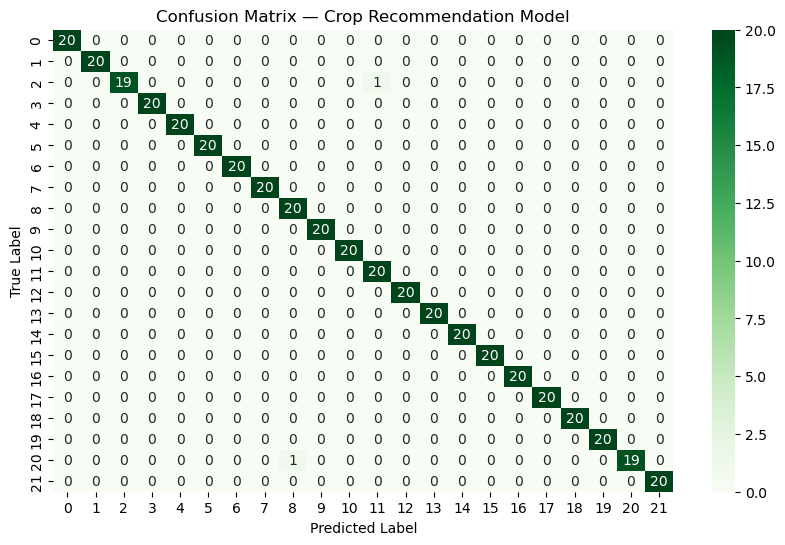

In [4]:

# Step 4: Confusion Matrix Visualization
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.title('Confusion Matrix — Crop Recommendation Model')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [5]:

# Step 5: Hyperparameter Tuning (Random Forest)
param_grid = {
    'n_estimators': [50, 100, 150],
    'max_depth': [5, 10, 15],
    'min_samples_split': [2, 5, 10]
}

rf = RandomForestClassifier(random_state=42)
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=3, n_jobs=-1, verbose=1)
grid_search.fit(X_test, y_test.values.ravel())

print("Best Parameters Found:")
print(grid_search.best_params_)

Fitting 3 folds for each of 27 candidates, totalling 81 fits
Best Parameters Found:
{'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 100}


In [6]:

# Step 6: Evaluate Tuned Model
best_model = grid_search.best_estimator_
y_pred_tuned = best_model.predict(X_test)

tuned_acc = accuracy_score(y_test, y_pred_tuned)
print(f"Tuned Model Accuracy: {tuned_acc * 100:.2f}%\n")
print("Tuned Model Report:")
print(classification_report(y_test, y_pred_tuned))

Tuned Model Accuracy: 100.00%

Tuned Model Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        20
           1       1.00      1.00      1.00        20
           2       1.00      1.00      1.00        20
           3       1.00      1.00      1.00        20
           4       1.00      1.00      1.00        20
           5       1.00      1.00      1.00        20
           6       1.00      1.00      1.00        20
           7       1.00      1.00      1.00        20
           8       1.00      1.00      1.00        20
           9       1.00      1.00      1.00        20
          10       1.00      1.00      1.00        20
          11       1.00      1.00      1.00        20
          12       1.00      1.00      1.00        20
          13       1.00      1.00      1.00        20
          14       1.00      1.00      1.00        20
          15       1.00      1.00      1.00        20
          16       1.00      1

In [7]:

# Step 7: Save the Tuned Model
with open('../models/crop_model_tuned.pkl', 'wb') as f:
    pickle.dump(best_model, f)

print("Tuned model saved as crop_model_tuned.pkl")

Tuned model saved as crop_model_tuned.pkl



### Summary
- Evaluated the original model on test data  
- Visualized confusion matrix  
- Tuned Random Forest parameters using GridSearchCV  
- Improved and saved the **tuned model**  